# CyberSentinel — Complete Training & Evaluation Pipeline
## AI-Powered Behavioral Anomaly Detection for Cybersecurity
**Honeywell Hackathon 2026**

---

This notebook walks through the **complete ML pipeline** step by step:

| Step | Description | Model/Technique |
|------|-------------|----------------|
| 1 | Data Loading | Synthetic access logs (50K events) |
| 2 | Exploratory Data Analysis | Class distribution, temporal patterns |
| 3 | Preprocessing & Feature Engineering | 28 behavioral features |
| 4 | Train/Test Split | Temporal split (80/20) |
| 5 | Baseline Profiler | Isolation Forest + One-Class SVM |
| 6 | Sequence Detection (LSTM) | LSTM Autoencoder |
| 7 | Sequence Detection (Transformer) | Transformer Encoder |
| 8 | Multi-Class Classifier | XGBoost with SMOTE |
| 9 | Multi-Class Classifier | Random Forest (comparison) |
| 10 | Evaluation | Confusion Matrix, ROC/AUC, Per-Attack Recall |
| 11 | Explainability | SHAP (beeswarm, waterfall, force plots) |
| 12 | Model Comparison | All 6 models — real metrics |
| 13 | Risk Scoring | Weighted ensemble → severity tiers |

> **Note:** This notebook **loads pre-trained models** from the `models/` directory.
> Run `python train_pipeline.py` first to train all 6 models.

In [23]:
# === Standard libraries ===
import sys, os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

# === ML evaluation metrics ===
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, roc_auc_score,
    precision_score, recall_score, f1_score, accuracy_score
)
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# === Suppress noisy warnings for cleaner output ===
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# === Configure matplotlib for inline display ===
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# === Add project root to Python path so we can import our modules ===
sys.path.insert(0, os.path.abspath('.'))
from config import DATA_DIR, MODELS_DIR, ANOMALY_TYPES, ANOMALY_DESCRIPTIONS, SEVERITY_TIERS

print("=" * 60)
print("  All imports loaded successfully!")
print("=" * 60)
print(f"  Data directory:   {DATA_DIR}")
print(f"  Models directory: {MODELS_DIR}")

  All imports loaded successfully!
  Data directory:   e:\cybersecurity_anomaly_detection\data
  Models directory: e:\cybersecurity_anomaly_detection\models


---
## 1. Data Loading

We load the synthetic access log dataset generated by `src/data_generator.py`.
The data simulates 90 days of authentication events across 200 entities
(users, service accounts, edge devices) with 7 types of injected attacks.

In [24]:
# Load the generated datasets from disk
full_df = pd.read_csv(DATA_DIR / 'access_logs.csv')
train_df = pd.read_csv(DATA_DIR / 'train.csv')
test_df = pd.read_csv(DATA_DIR / 'test.csv')

# Print the same stats that train_pipeline.py shows in terminal
print("=" * 70)
print("  STEP 1: Data Loading")
print("=" * 70)
print(f"  Full dataset:  {len(full_df):,} events")
print(f"  Training set:  {len(train_df):,} events ({len(train_df)/len(full_df)*100:.0f}%)")
print(f"  Test set:      {len(test_df):,} events ({len(test_df)/len(full_df)*100:.0f}%)")
print(f"  Columns ({len(full_df.columns)}): {list(full_df.columns)}")
print(f"  Date range: {full_df['timestamp'].min()} to {full_df['timestamp'].max()}")
print(f"  Unique entities: {full_df['entity_id'].nunique()}")

# Attack breakdown — matches terminal output from data generator
total = len(full_df)
anomaly_count = len(full_df[full_df['label'] != 'normal'])
print(f"\n  Normal:  {total - anomaly_count:,} ({(total-anomaly_count)/total*100:.1f}%)")
print(f"  Anomaly: {anomaly_count:,} ({anomaly_count/total*100:.1f}%)")
print("\n  Attack breakdown:")
for label in sorted(full_df['label'].unique()):
    if label != 'normal':
        count = len(full_df[full_df['label'] == label])
        print(f"    {label:25s}: {count:5d} ({count/total*100:.2f}%)")

# Show sample rows
print("\n  First 5 rows:")
display(full_df.head())

  STEP 1: Data Loading
  Full dataset:  50,153 events
  Training set:  40,122 events (80%)
  Test set:      10,031 events (20%)
  Columns (13): ['entity_id', 'entity_type', 'timestamp', 'source_ip', 'geo_location', 'geo_city', 'resource_accessed', 'auth_method', 'session_duration', 'command_sequence', 'device_fingerprint', 'auth_success', 'label']
  Date range: 2026-04-01 00:00:30 to 2026-06-29 23:55:20
  Unique entities: 200

  Normal:  48,643 (97.0%)
  Anomaly: 1,510 (3.0%)

  Attack breakdown:
    brute_force              :   360 (0.72%)
    credential_stuffing      :   166 (0.33%)
    device_spoofing          :   150 (0.30%)
    impossible_travel        :   150 (0.30%)
    insider_drift            :   294 (0.59%)
    lateral_movement         :   210 (0.42%)
    low_and_slow             :   180 (0.36%)

  First 5 rows:


,entity_id,entity_type,timestamp,source_ip,geo_location,geo_city,resource_accessed,auth_method,session_duration,command_sequence,device_fingerprint,auth_success,label
0,DEV_0024,edge_device,2026-04-01 00:00:30,153.170.164.225,"25.2366,55.3212",Dubai,/telemetry/vibration,token,718,"[""handshake"", ""send_telemetry"", ""ack""]",VxWorks 7|68:19:07:2f:79:55|MQTT,True,normal
1,SVC_0062,service_account,2026-04-01 00:03:06,17.73.203.110,"-33.8888,151.2873",Sydney,/api/v1/data/export,token,78,"[""authenticate"", ""run_backup"", ""verify_backup""]",Debian 12|a6:f0:09:1a:b3:72|HTTPS,True,normal
2,SVC_0150,service_account,2026-04-01 00:04:51,184.202.32.108,"-23.5989,-46.6968",São Paulo,/api/v1/certs/renew,token,83,"[""authenticate"", ""run_backup"", ""verify_backup""]",Ubuntu 22.04 Server|78:a5:a1:4d:e1:22|gRPC,True,normal
3,DEV_0024,edge_device,2026-04-01 00:05:31,153.170.164.225,"25.1322,55.2359",Dubai,/telemetry/vibration,certificate,867,"[""handshake"", ""send_telemetry"", ""ack""]",VxWorks 7|68:19:07:2f:79:55|MQTT,True,normal
4,SVC_0087,service_account,2026-04-01 00:08:09,184.3.3.141,"39.9278,116.3334",Beijing,/api/v1/config/update,token,43,"[""authenticate"", ""run_backup"", ""verify_backup""]",RHEL 9|e2:8b:fc:e0:29:14|gRPC,True,normal


---
## 2. Exploratory Data Analysis (EDA)

Before building models, we explore the dataset to understand:
- **Class distribution** — How imbalanced is the data?
- **Temporal patterns** — When do attacks happen?
- **Entity behavior** — Which entity types are targeted?
- **Authentication patterns** — Which auth methods fail?

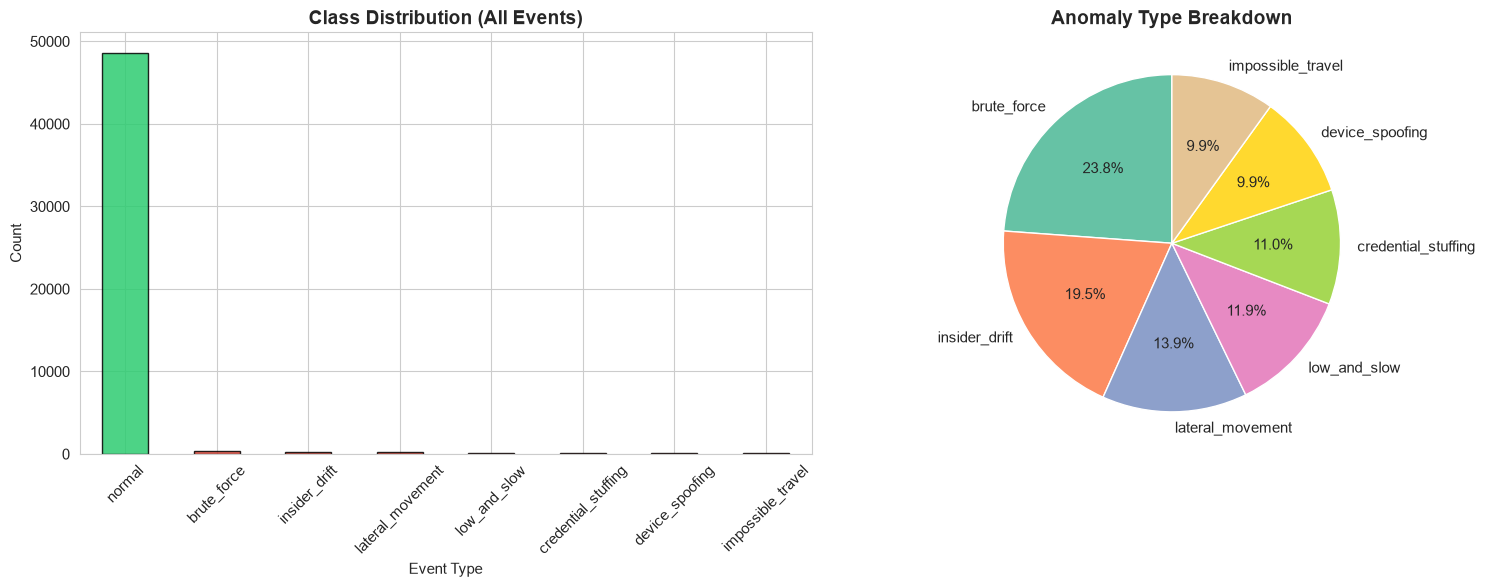

Imbalance ratio (normal:rarest attack): 48643/150 = 324:1
=> Extreme class imbalance — we use SMOTE oversampling for the classifier


In [25]:
# === Class Distribution ===
# Shows the extreme imbalance between normal and attack events
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart — all classes including normal
class_counts = full_df['label'].value_counts()
colors = ['#2ecc71' if x == 'normal' else '#e74c3c' for x in class_counts.index]
class_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Class Distribution (All Events)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Event Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart — anomaly types only (excludes normal for clarity)
anomaly_counts = full_df[full_df['label'] != 'normal']['label'].value_counts()
anomaly_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90,
                    colors=sns.color_palette('Set2', len(anomaly_counts)))
axes[1].set_title('Anomaly Type Breakdown', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Print imbalance ratio — this is why we need SMOTE
print(f"Imbalance ratio (normal:rarest attack): {class_counts.max()}/{class_counts.min()} = {class_counts.max()/class_counts.min():.0f}:1")
print("=> Extreme class imbalance — we use SMOTE oversampling for the classifier")

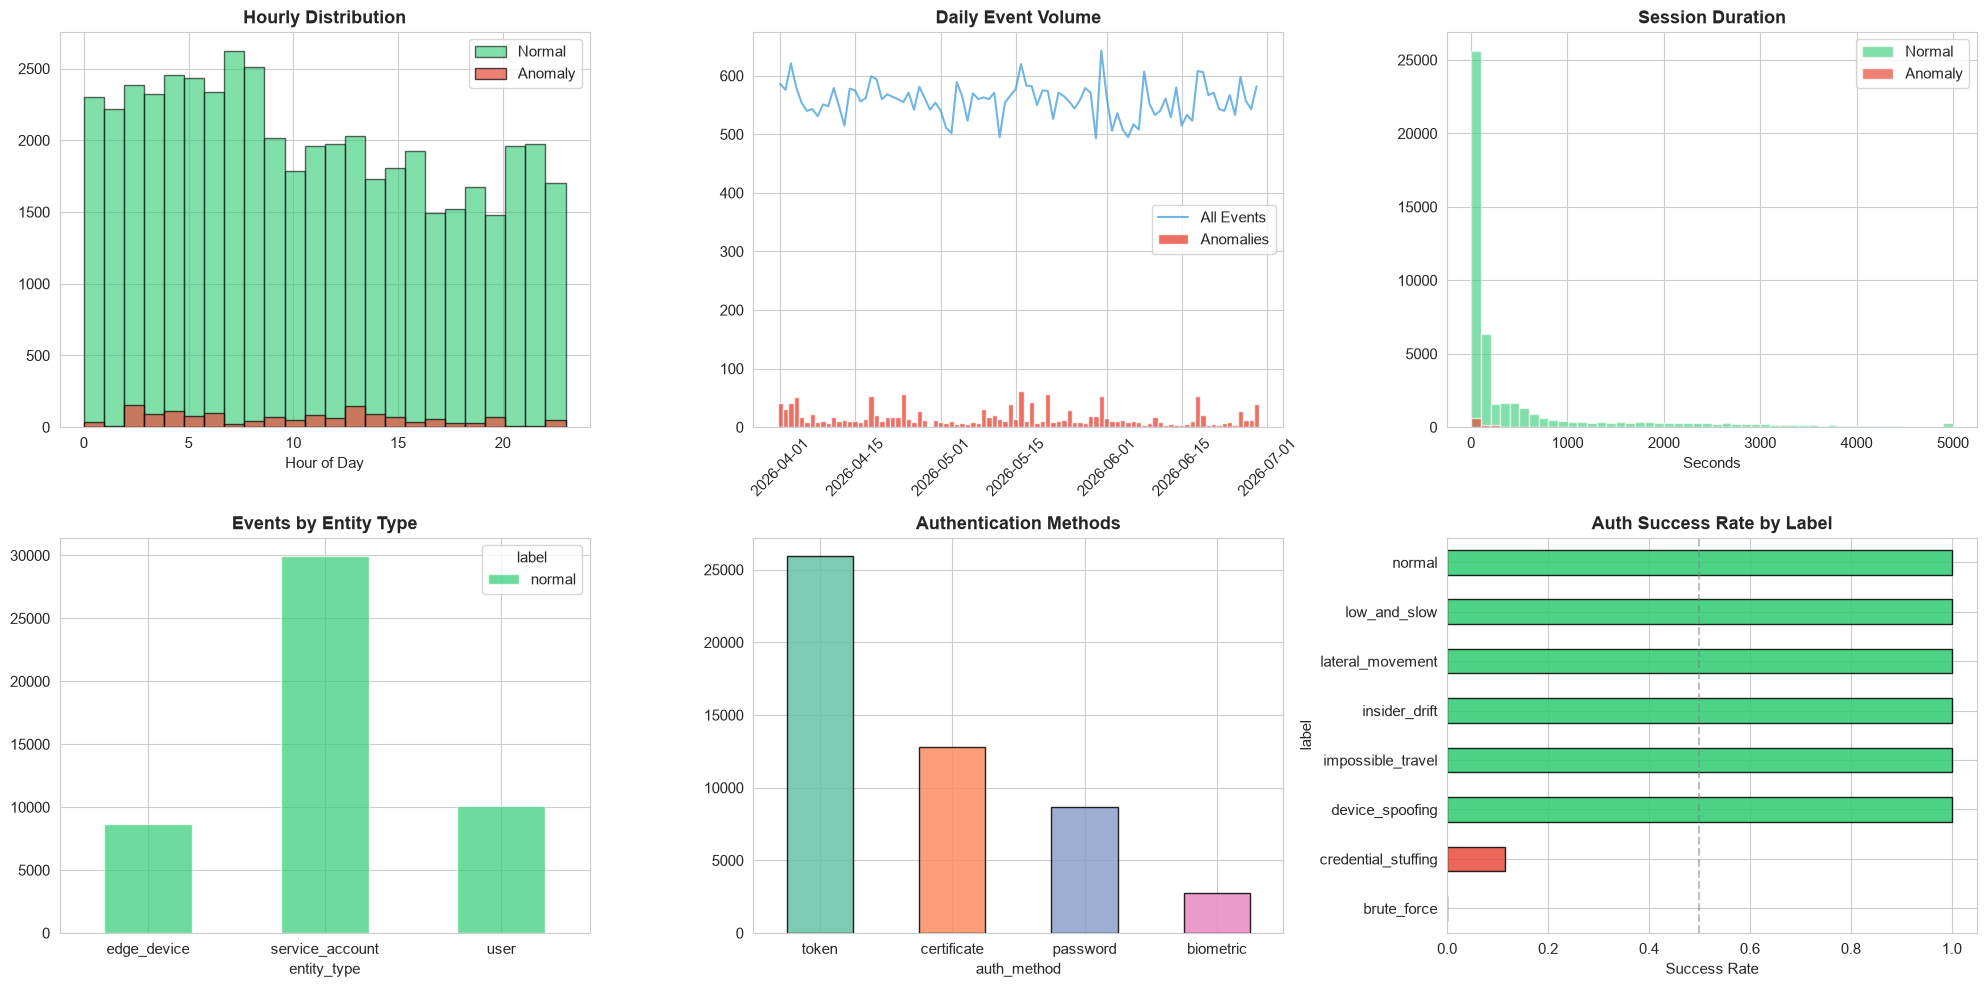

In [26]:
# === Temporal, Entity Type & Auth Analysis ===
full_df['timestamp'] = pd.to_datetime(full_df['timestamp'])
full_df['hour'] = full_df['timestamp'].dt.hour

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# 1. Hourly distribution — when do normal vs anomaly events happen?
normal_hours = full_df[full_df['label'] == 'normal']['hour']
anomaly_hours = full_df[full_df['label'] != 'normal']['hour']
axes[0,0].hist(normal_hours, bins=24, alpha=0.6, label='Normal', color='#2ecc71', edgecolor='black')
axes[0,0].hist(anomaly_hours, bins=24, alpha=0.7, label='Anomaly', color='#e74c3c', edgecolor='black')
axes[0,0].set_title('Hourly Distribution', fontweight='bold')
axes[0,0].set_xlabel('Hour of Day')
axes[0,0].legend()

# 2. Events over time (daily volume)
daily = full_df.groupby(full_df['timestamp'].dt.date).size()
daily_anom = full_df[full_df['label'] != 'normal'].groupby(
    full_df[full_df['label'] != 'normal']['timestamp'].dt.date).size()
axes[0,1].plot(daily.index, daily.values, color='#3498db', alpha=0.7, label='All Events')
axes[0,1].bar(daily_anom.index, daily_anom.values, color='#e74c3c', alpha=0.8, label='Anomalies', width=1)
axes[0,1].set_title('Daily Event Volume', fontweight='bold')
axes[0,1].legend()
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Session duration — anomalies often have unusual durations
normal_dur = full_df[full_df['label'] == 'normal']['session_duration'].clip(upper=5000)
anomaly_dur = full_df[full_df['label'] != 'normal']['session_duration'].clip(upper=5000)
axes[0,2].hist(normal_dur, bins=50, alpha=0.6, label='Normal', color='#2ecc71')
axes[0,2].hist(anomaly_dur, bins=50, alpha=0.7, label='Anomaly', color='#e74c3c')
axes[0,2].set_title('Session Duration', fontweight='bold')
axes[0,2].set_xlabel('Seconds')
axes[0,2].legend()

# 4. Entity type distribution
entity_type_label = full_df.groupby(['entity_type', 'label']).size().unstack(fill_value=0)
entity_type_label[['normal']].plot(kind='bar', ax=axes[1,0], color='#2ecc71', alpha=0.7)
axes[1,0].set_title('Events by Entity Type', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=0)

# 5. Auth method usage
auth_counts = full_df['auth_method'].value_counts()
auth_counts.plot(kind='bar', ax=axes[1,1], color=sns.color_palette('Set2', len(auth_counts)),
                 edgecolor='black', alpha=0.85)
axes[1,1].set_title('Authentication Methods', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=0)

# 6. Auth success rate by label — brute force and credential stuffing have high failure
success_by_type = full_df.groupby('label')['auth_success'].apply(
    lambda x: (x.astype(str).str.lower() == 'true').mean()
).sort_values()
colors_auth = ['#e74c3c' if v < 0.5 else '#f39c12' if v < 0.9 else '#2ecc71' for v in success_by_type.values]
success_by_type.plot(kind='barh', ax=axes[1,2], color=colors_auth, edgecolor='black', alpha=0.85)
axes[1,2].set_title('Auth Success Rate by Label', fontweight='bold')
axes[1,2].set_xlabel('Success Rate')
axes[1,2].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
## 3. Preprocessing & Feature Engineering

Raw access logs are transformed into **28 numerical features** for ML models:
- **Temporal features**: hour, day_of_week, is_weekend, is_night (with cyclical encoding)
- **Geographic features**: latitude, longitude, geo_distance, geo_velocity
- **Behavioral features**: session_duration, cmd_count, suspicious commands, auth success
- **Entity statistics**: hour_deviation, duration_deviation, time_gap, cumulative unique resources
- **Encoded categoricals**: entity_type, auth_method, resource_accessed

All features are **StandardScaler normalized** (zero mean, unit variance).

[FeatureEng] Extracted 28 features from 40122 events
  STEP 2: Feature Engineering
  Feature matrix: train=(40122, 28), test=(10031, 28)
  Features (28):
     1. hour
     2. day_of_week
     3. is_weekend
     4. is_night
     5. minute_of_day
     6. hour_sin
     7. hour_cos
     8. dow_sin
     9. dow_cos
    10. latitude
    11. longitude
    12. session_duration
    13. log_session_duration
    14. cmd_count
    15. has_suspicious_cmd
    16. fingerprint_parts
    17. auth_success_int
    18. hour_deviation
    19. duration_deviation
    20. time_gap_seconds
    21. log_time_gap
    22. geo_distance_km
    23. geo_velocity_kmh
    24. cumulative_unique_resources
    25. entity_event_count
    26. entity_type_enc
    27. auth_method_enc
    28. resource_enc

  Label encoding (LabelEncoder alphabetical order):
    0 = brute_force
    1 = credential_stuffing
    2 = device_spoofing
    3 = impossible_travel
    4 = insider_drift
    5 = lateral_movement
    6 = low_and_slow
    7 = 

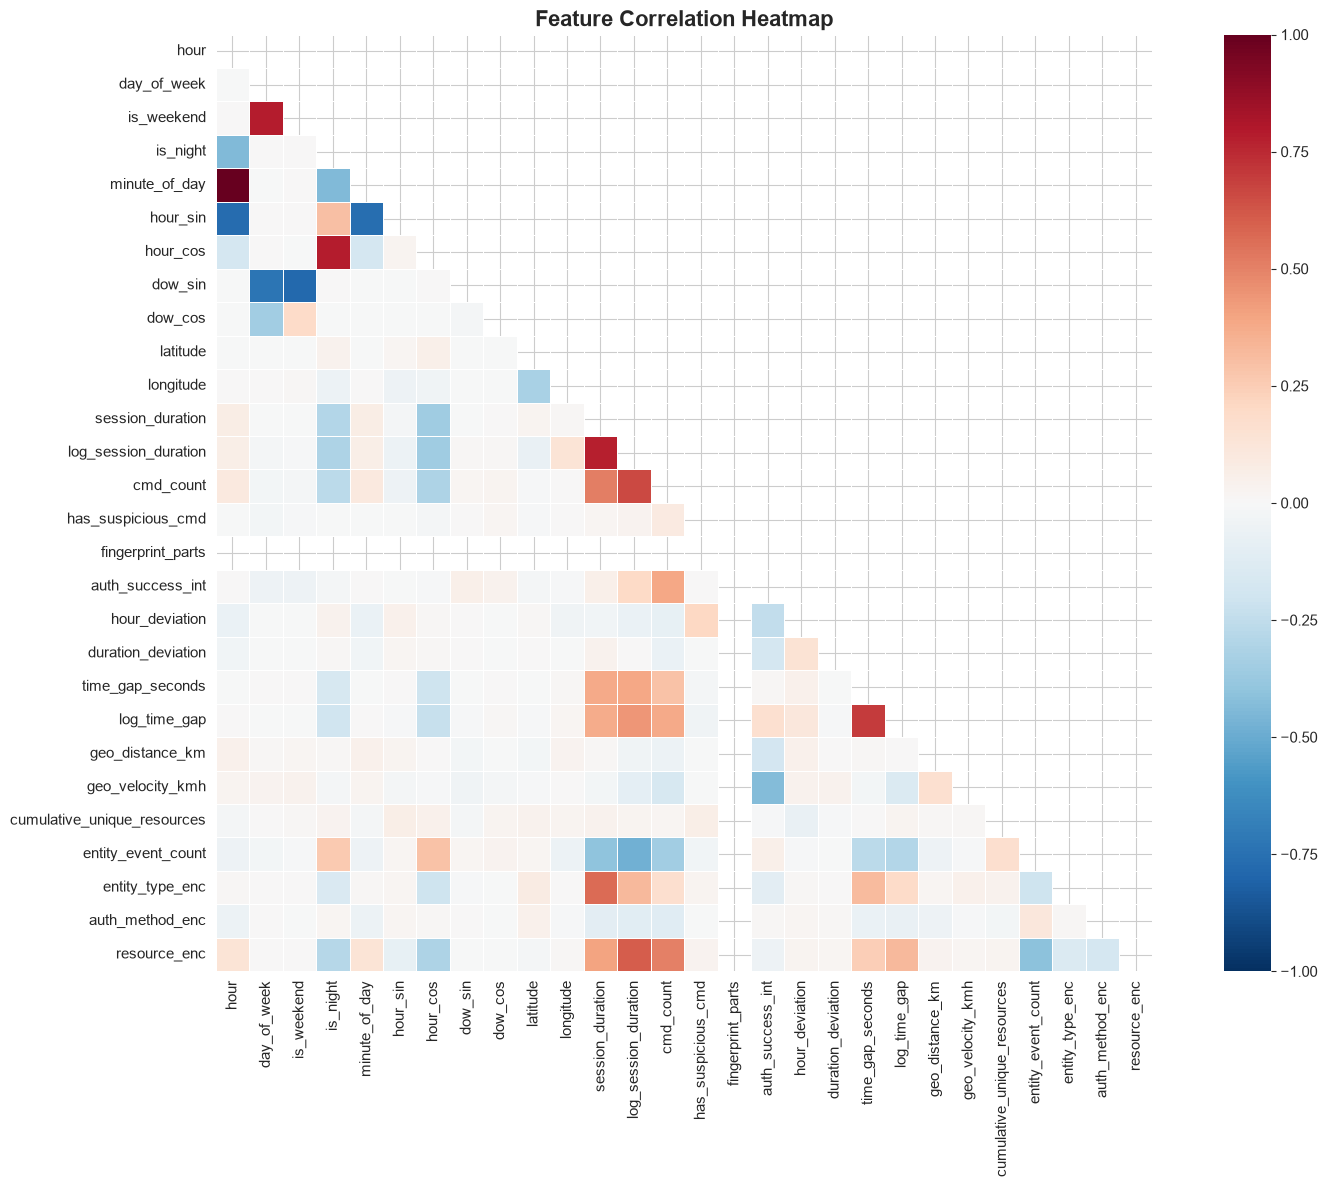


Highly correlated pairs (|r| > 0.8):
  hour <-> minute_of_day: 0.999


In [27]:
# Load the pre-fitted feature engineer (saves time vs re-fitting)
feature_eng = joblib.load(MODELS_DIR / 'feature_engineer.pkl')
label_encoder = joblib.load(MODELS_DIR / 'label_encoder.pkl')

# Transform train and test data using the fitted feature engineer
X_train, y_train, train_feat_df = feature_eng.fit_transform(train_df)
X_test, y_test, test_feat_df = feature_eng.transform(test_df)

# Show feature names and matrix shape
feature_names = feature_eng.get_feature_names()
print("=" * 70)
print("  STEP 2: Feature Engineering")
print("=" * 70)
print(f"  Feature matrix: train={X_train.shape}, test={X_test.shape}")
print(f"  Features ({len(feature_names)}):")
for i, name in enumerate(feature_names):
    print(f"    {i+1:2d}. {name}")

print(f"\n  Label encoding (LabelEncoder alphabetical order):")
for i, cls in enumerate(label_encoder.classes_):
    print(f"    {i} = {cls}")

# === Correlation Heatmap ===
# Shows which features are correlated — helps identify redundancy
feat_df = pd.DataFrame(X_train, columns=feature_names)
corr = feat_df.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Hide upper triangle (symmetric)
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, annot=False,
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nHighly correlated pairs (|r| > 0.8):")
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        if abs(corr.iloc[i, j]) > 0.8:
            print(f"  {corr.index[i]} <-> {corr.columns[j]}: {corr.iloc[i,j]:.3f}")

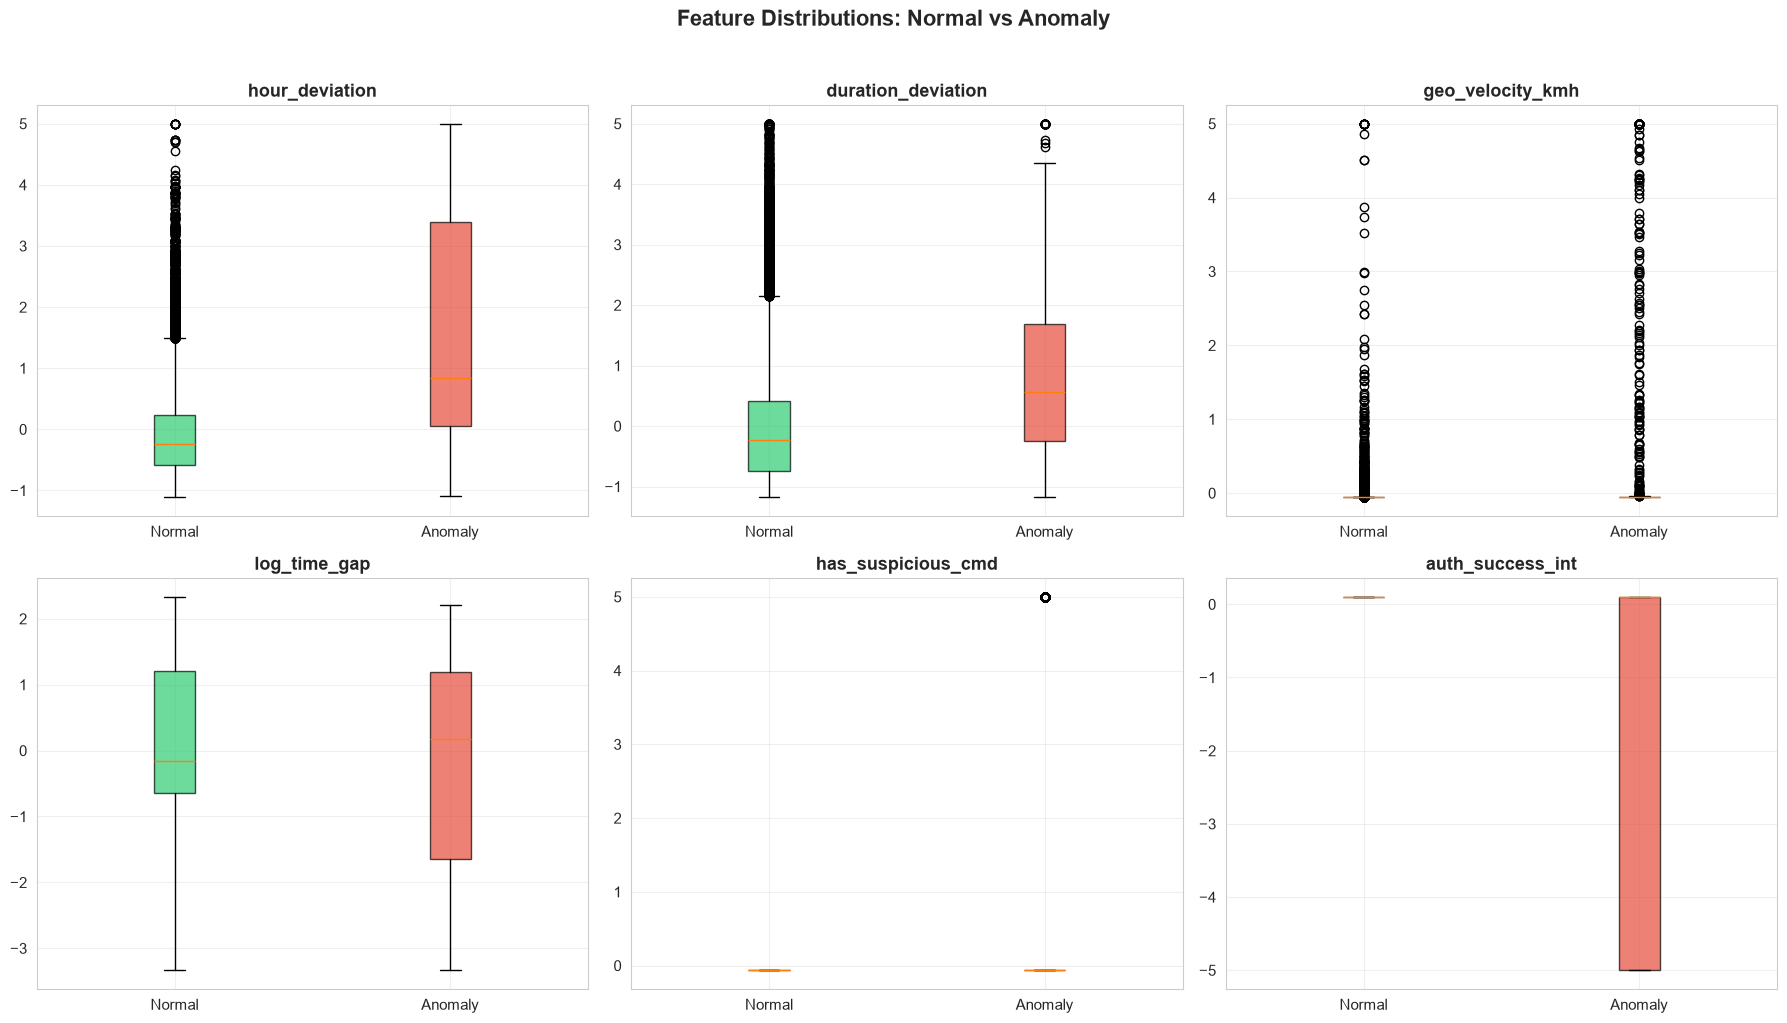

In [28]:
# === Feature Distributions by Class ===
# Compare how key features differ between normal and anomaly events
key_features = ['hour_deviation', 'duration_deviation', 'geo_velocity_kmh',
                'log_time_gap', 'has_suspicious_cmd', 'auth_success_int']

# Create binary label column for coloring
feat_df_plot = pd.DataFrame(X_train, columns=feature_names)
normal_enc = label_encoder.transform(['normal'])[0]
feat_df_plot['is_anomaly'] = (y_train != normal_enc).astype(int)
feat_df_plot['label'] = ['Anomaly' if a else 'Normal' for a in feat_df_plot['is_anomaly']]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, feat in enumerate(key_features):
    ax = axes[idx // 3, idx % 3]
    if feat in feat_df_plot.columns:
        # Box plot comparing normal vs anomaly distributions
        data_normal = feat_df_plot[feat_df_plot['label'] == 'Normal'][feat].clip(-5, 5)
        data_anomaly = feat_df_plot[feat_df_plot['label'] == 'Anomaly'][feat].clip(-5, 5)
        bp = ax.boxplot([data_normal, data_anomaly], tick_labels=['Normal', 'Anomaly'], patch_artist=True)
        bp['boxes'][0].set_facecolor('#2ecc71')
        bp['boxes'][0].set_alpha(0.7)
        bp['boxes'][1].set_facecolor('#e74c3c')
        bp['boxes'][1].set_alpha(0.7)
    ax.set_title(feat, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Feature Distributions: Normal vs Anomaly', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Train/Test Split

We use a **temporal split** (not random) — earlier 80% of events for training,
later 20% for testing. This simulates real-world deployment where the model
is trained on historical data and evaluated on future events.

  STEP 3: Train/Test Split (Temporal)
  Training:  40,122 events (80%)
  Testing:   10,031 events (20%)

  Class distribution in train set:
    brute_force              :   272
    credential_stuffing      :   166
    device_spoofing          :   111
    impossible_travel        :   122
    insider_drift            :   273
    lateral_movement         :   162
    low_and_slow             :   175
    normal                   : 38841

  Class distribution in test set:
    brute_force              :    88
    device_spoofing          :    39
    impossible_travel        :    28
    insider_drift            :    21
    lateral_movement         :    48
    low_and_slow             :     5
    normal                   :  9802


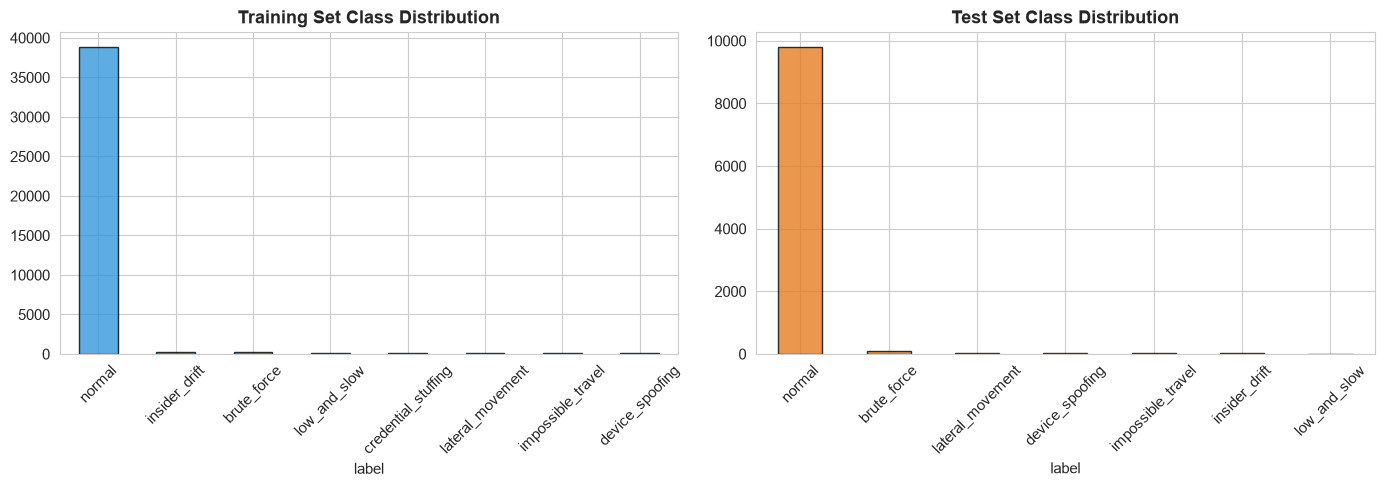

In [29]:
# Show train/test split statistics
print("=" * 70)
print("  STEP 3: Train/Test Split (Temporal)")
print("=" * 70)
print(f"  Training:  {len(train_df):,} events ({len(train_df)/len(full_df)*100:.0f}%)")
print(f"  Testing:   {len(test_df):,} events ({len(test_df)/len(full_df)*100:.0f}%)")

# Class counts in each split
print("\n  Class distribution in train set:")
for label in sorted(train_df['label'].unique()):
    count = len(train_df[train_df['label'] == label])
    print(f"    {label:25s}: {count:5d}")

print("\n  Class distribution in test set:")
for label in sorted(test_df['label'].unique()):
    count = len(test_df[test_df['label'] == label])
    print(f"    {label:25s}: {count:5d}")

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
train_counts = train_df['label'].value_counts()
test_counts = test_df['label'].value_counts()
train_counts.plot(kind='bar', ax=axes[0], color='#3498db', alpha=0.8, edgecolor='black')
axes[0].set_title('Training Set Class Distribution', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
test_counts.plot(kind='bar', ax=axes[1], color='#e67e22', alpha=0.8, edgecolor='black')
axes[1].set_title('Test Set Class Distribution', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## 5. Model 1: Baseline Profiler (Isolation Forest + One-Class SVM)

The **Baseline Profiler** learns what "normal" looks like for each entity:

1. **Statistical Profiles** — per-entity mean/std for login hour, session duration, geo distance
2. **Isolation Forest** (200 trees) — isolates anomalies by random partitioning
3. **One-Class SVM** (RBF kernel) — learns a boundary around normal data

All three are trained on **normal events only** (unsupervised anomaly detection).

[BaselineProfiler] Models loaded from disk.
  STEP 4: Baseline Profiler Results
  Mean IF score (train):  0.3253
  Mean IF score (test):   0.3245
  Mean SVM score (test):  0.3271
  Mean Stat score (test): 0.2110


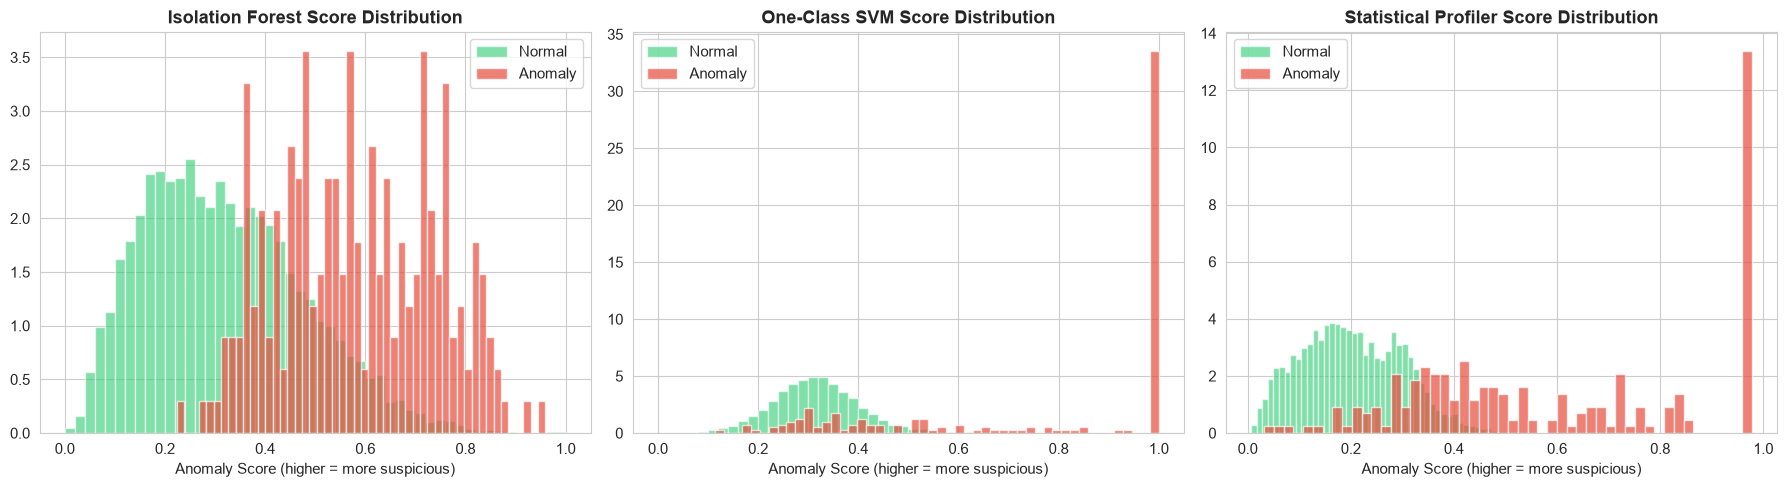

In [30]:
# Load pre-trained baseline models
from src.baseline_profiler import BaselineProfiler
profiler = BaselineProfiler()
profiler.load_models()

# Score the test data using all 3 baseline models
test_baseline_scores = profiler.score(X_test, test_feat_df)
train_baseline_scores = profiler.score(X_train, train_feat_df)

print("=" * 70)
print("  STEP 4: Baseline Profiler Results")
print("=" * 70)
print(f"  Mean IF score (train):  {train_baseline_scores['isolation_forest_score'].mean():.4f}")
print(f"  Mean IF score (test):   {test_baseline_scores['isolation_forest_score'].mean():.4f}")
print(f"  Mean SVM score (test):  {test_baseline_scores['one_class_svm_score'].mean():.4f}")
print(f"  Mean Stat score (test): {test_baseline_scores['statistical_score'].mean():.4f}")

# Plot score distributions — anomalies should have higher scores
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
score_names = ['isolation_forest_score', 'one_class_svm_score', 'statistical_score']
titles = ['Isolation Forest', 'One-Class SVM', 'Statistical Profiler']

for i, (sname, title) in enumerate(zip(score_names, titles)):
    scores = test_baseline_scores[sname]
    normal_scores = scores[y_test == normal_enc]
    anomaly_scores = scores[y_test != normal_enc]
    axes[i].hist(normal_scores, bins=50, alpha=0.6, label='Normal', color='#2ecc71', density=True)
    axes[i].hist(anomaly_scores, bins=50, alpha=0.7, label='Anomaly', color='#e74c3c', density=True)
    axes[i].set_title(f'{title} Score Distribution', fontweight='bold')
    axes[i].set_xlabel('Anomaly Score (higher = more suspicious)')
    axes[i].legend()

plt.tight_layout()
plt.show()

---
## 6. Model 2: LSTM Autoencoder (Sequence Detection)

The **LSTM Autoencoder** captures temporal patterns that static models miss:

- **Input**: sliding windows of 10 consecutive events per entity
- **Architecture**: Encoder (LSTM 64→32) → Latent Space → Decoder (LSTM 32→64)
- **Training**: on normal sequences only (reconstruction learning)
- **Detection**: high reconstruction error = sequence doesn't match normal patterns

This is our **deep learning** layer — it catches attacks like "low-and-slow"
that span multiple events over time.

[LSTM-AE] Model loaded from disk.
  STEP 5: LSTM Autoencoder Results
  Reconstruction threshold (p97.5): 0.369113
  Mean LSTM score (test): 0.0128
  Max LSTM score (test):  1.0000

  LSTM Model Architecture:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 10, 64)         │        23,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 10, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 10, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 28)         │         1,820 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,196 (278.11 KB)

 Trainable params: 71,196 (278.11 KB)

 Non-trainable params: 0 (0.00 B)

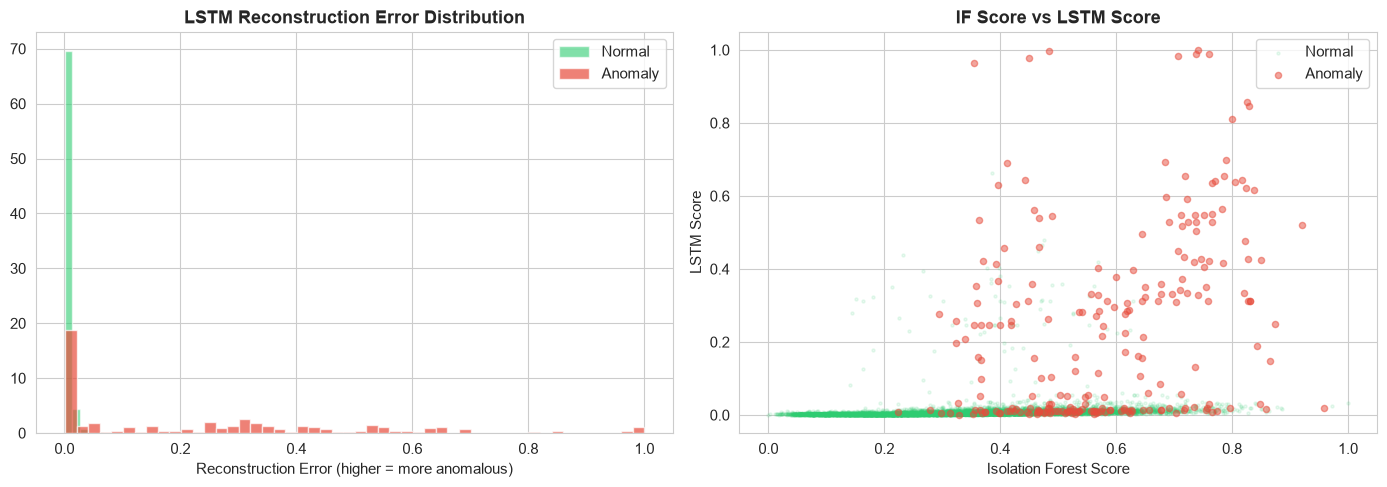

In [31]:
# Load pre-trained LSTM Autoencoder
from src.detection_model import LSTMAutoencoder
lstm = LSTMAutoencoder()
lstm.load()

# Score test data — reconstruction error per event
entity_ids_test = test_feat_df['entity_id'].values
entity_ids_train = train_feat_df['entity_id'].values
lstm_test_scores = lstm.score(X_test, entity_ids_test)

print("=" * 70)
print("  STEP 5: LSTM Autoencoder Results")
print("=" * 70)
print(f"  Reconstruction threshold (p97.5): {lstm.threshold:.6f}")
print(f"  Mean LSTM score (test): {lstm_test_scores.mean():.4f}")
print(f"  Max LSTM score (test):  {lstm_test_scores.max():.4f}")

# Print model architecture
print("\n  LSTM Model Architecture:")
lstm.model.summary()

# Plot reconstruction error distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution: normal vs anomaly
normal_lstm = lstm_test_scores[y_test == normal_enc]
anomaly_lstm = lstm_test_scores[y_test != normal_enc]
axes[0].hist(normal_lstm, bins=50, alpha=0.6, label='Normal', color='#2ecc71', density=True)
axes[0].hist(anomaly_lstm, bins=50, alpha=0.7, label='Anomaly', color='#e74c3c', density=True)
axes[0].set_title('LSTM Reconstruction Error Distribution', fontweight='bold')
axes[0].set_xlabel('Reconstruction Error (higher = more anomalous)')
axes[0].legend()

# Scatter: LSTM score vs IF score — shows how models complement each other
axes[1].scatter(test_baseline_scores['isolation_forest_score'][y_test == normal_enc],
               lstm_test_scores[y_test == normal_enc], alpha=0.1, s=5, color='#2ecc71', label='Normal')
axes[1].scatter(test_baseline_scores['isolation_forest_score'][y_test != normal_enc],
               lstm_test_scores[y_test != normal_enc], alpha=0.5, s=20, color='#e74c3c', label='Anomaly')
axes[1].set_title('IF Score vs LSTM Score', fontweight='bold')
axes[1].set_xlabel('Isolation Forest Score')
axes[1].set_ylabel('LSTM Score')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 7. Model 3: Transformer Detector (Sequence Detection — Comparison)

The **Transformer Detector** is an alternative to the LSTM Autoencoder for
sequence-based anomaly detection, as suggested in the problem statement:

> *"Detection model — sequence-aware approach (LSTM/GRU, **Transformer**, or graph-based)"*

| | LSTM Autoencoder | Transformer |
|---|---|---|
| Attention | No (sequential only) | Yes (self-attention, captures non-local patterns) |
| Architecture | Encoder → Latent → Decoder | Positional Encoding → Multi-Head Attention → Dense |
| Training | Normal-only sequences | Normal-only sequences |
| Detection | Reconstruction error | Reconstruction error |

Both use the same input (sliding windows of 10 events) and the same anomaly
detection approach (high reconstruction error = anomaly). The comparison
tells us whether attention-based modeling adds value over recurrent modeling.

[Transformer] Model loaded from disk.
  STEP 5b: Transformer Detector Results
  Reconstruction threshold (p97.5): 0.000158
  Mean Transformer score (test): 0.0091
  Max Transformer score (test):  1.0000

  Transformer Model Architecture:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 10, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 10, 64)    │      1,856 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 10, 64)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 64)    │     16,640 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 10, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 10, 64)    │          0 │ add[0][0],        │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 10, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 10, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 10, 64)    │      8,256 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 10, 64)    │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 10, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 10, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 10, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 10, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 10, 64)    │      8,256 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 10, 64)    │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 10, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_5[0][0] 

 Total params: 70,620 (275.86 KB)

 Trainable params: 70,620 (275.86 KB)

 Non-trainable params: 0 (0.00 B)

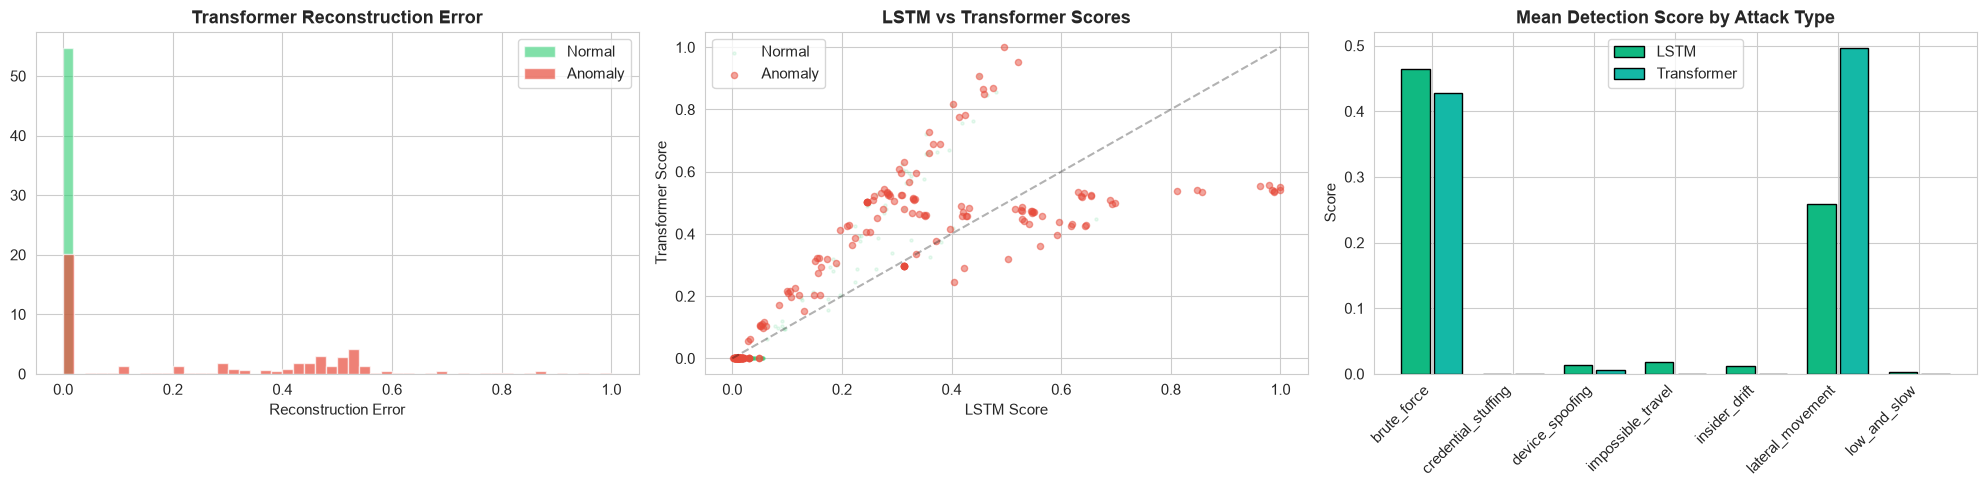


  LSTM vs Transformer Summary:
  LSTM mean anomaly score:        0.2386
  Transformer mean anomaly score: 0.2692


In [32]:
# Load pre-trained Transformer Detector
from src.detection_model import TransformerDetector
transformer = TransformerDetector()
transformer.load()

# Score test data — reconstruction error per event
transformer_test_scores = transformer.score(X_test, entity_ids_test)

print("=" * 70)
print("  STEP 5b: Transformer Detector Results")
print("=" * 70)
print(f"  Reconstruction threshold (p97.5): {transformer.threshold:.6f}")
print(f"  Mean Transformer score (test): {transformer_test_scores.mean():.4f}")
print(f"  Max Transformer score (test):  {transformer_test_scores.max():.4f}")

# Print model architecture
print("\n  Transformer Model Architecture:")
transformer.model.summary()

# Plot: LSTM vs Transformer score comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Transformer score distribution
normal_trans = transformer_test_scores[y_test == normal_enc]
anomaly_trans = transformer_test_scores[y_test != normal_enc]
axes[0].hist(normal_trans, bins=50, alpha=0.6, label='Normal', color='#2ecc71', density=True)
axes[0].hist(anomaly_trans, bins=50, alpha=0.7, label='Anomaly', color='#e74c3c', density=True)
axes[0].set_title('Transformer Reconstruction Error', fontweight='bold')
axes[0].set_xlabel('Reconstruction Error')
axes[0].legend()

# 2. LSTM vs Transformer scatter — do they agree on which events are anomalous?
axes[1].scatter(lstm_test_scores[y_test == normal_enc],
               transformer_test_scores[y_test == normal_enc],
               alpha=0.1, s=5, color='#2ecc71', label='Normal')
axes[1].scatter(lstm_test_scores[y_test != normal_enc],
               transformer_test_scores[y_test != normal_enc],
               alpha=0.5, s=20, color='#e74c3c', label='Anomaly')
axes[1].set_title('LSTM vs Transformer Scores', fontweight='bold')
axes[1].set_xlabel('LSTM Score')
axes[1].set_ylabel('Transformer Score')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].legend()

# 3. Side-by-side box plot for each attack type
import matplotlib.patches as mpatches
attack_types = [c for c in label_encoder.classes_ if c != 'normal']
lstm_means = []
trans_means = []
for attack in attack_types:
    enc = label_encoder.transform([attack])[0]
    mask = y_test == enc
    lstm_means.append(lstm_test_scores[mask].mean() if mask.sum() > 0 else 0)
    trans_means.append(transformer_test_scores[mask].mean() if mask.sum() > 0 else 0)

x_pos = np.arange(len(attack_types))
axes[2].bar(x_pos - 0.2, lstm_means, 0.35, label='LSTM', color='#10B981', edgecolor='black')
axes[2].bar(x_pos + 0.2, trans_means, 0.35, label='Transformer', color='#14B8A6', edgecolor='black')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(attack_types, rotation=45, ha='right')
axes[2].set_title('Mean Detection Score by Attack Type', fontweight='bold')
axes[2].set_ylabel('Score')
axes[2].legend()

plt.tight_layout()
plt.show()

print("\n  LSTM vs Transformer Summary:")
print(f"  LSTM mean anomaly score:        {lstm_test_scores[y_test != normal_enc].mean():.4f}")
print(f"  Transformer mean anomaly score: {transformer_test_scores[y_test != normal_enc].mean():.4f}")

---
## 8. Model 4: XGBoost Multi-Class Classifier

Unlike the detection models (IF, SVM, LSTM, Transformer) which only detect
"is this anomalous?", **XGBoost classifies WHICH type of attack** an event resembles.

- **8 classes**: normal + 7 attack types
- **SMOTE oversampling**: creates synthetic minority samples to handle imbalance
- **Feature augmentation**: original 28 features + 4 baseline model scores = 32 inputs
- **300 trees, max_depth=6, learning_rate=0.1**

In [33]:
# Load pre-trained XGBoost classifier
from src.anomaly_classifier import AnomalyClassifier
classifier = AnomalyClassifier(label_encoder=label_encoder)
classifier.load()

# Evaluate on test data (same output as train_pipeline.py Step 5)
results = classifier.evaluate(X_test, y_test, baseline_scores=test_baseline_scores)

# Get predictions and probabilities for later use
xgb_preds = results['predictions']
xgb_proba = results['probabilities']

[Classifier] Model loaded from disk.

ANOMALY CLASSIFICATION REPORT
                     precision    recall  f1-score   support

        brute_force       1.00      0.62      0.77        88
credential_stuffing       0.00      0.00      0.00         0
    device_spoofing       0.71      0.51      0.60        39
  impossible_travel       0.70      0.25      0.37        28
      insider_drift       0.63      0.57      0.60        21
   lateral_movement       1.00      1.00      1.00        48
       low_and_slow       0.80      0.80      0.80         5
             normal       0.99      1.00      1.00      9802

           accuracy                           0.99     10031
          macro avg       0.73      0.59      0.64     10031
       weighted avg       0.99      0.99      0.99     10031

Confusion Matrix:
                     brute_force  credential_stuffing  device_spoofing  \
brute_force                   55                   33                0   
credential_stuffing            

---
## 9. Model 5: Random Forest (Classification — Comparison)

A **Random Forest classifier** trained alongside XGBoost for a direct comparison:

| | XGBoost | Random Forest |
|---|---------|--------------|
| Ensemble Type | Gradient Boosting (sequential) | Bagging (parallel) |
| Error Correction | Each tree fixes previous errors | Trees vote independently |
| Overfitting Risk | Lower (regularized) | Higher (deeper trees) |
| Speed | Slower training | Faster training |

> Both models use the same augmented features (28 + 4 baseline scores) and SMOTE.

In [34]:
# === Load pre-trained Random Forest ===
rf_model = joblib.load(MODELS_DIR / 'random_forest.pkl')
print("Random Forest model loaded from models/random_forest.pkl")
print(f"  Trees: {rf_model.n_estimators}, Max depth: {rf_model.max_depth}")

# Augment features with baseline scores (same as XGBoost gets)
X_test_aug = np.hstack([X_test] + [
    test_baseline_scores[k].reshape(-1, 1)
    for k in ['statistical_score', 'isolation_forest_score', 'one_class_svm_score', 'baseline_combined_score']
])

# Evaluate Random Forest
rf_preds = rf_model.predict(X_test_aug)
rf_proba = rf_model.predict_proba(X_test_aug)

# Classification report (same format as XGBoost)
present_labels = sorted(set(y_test) | set(rf_preds))
target_names = [label_encoder.inverse_transform([i])[0] for i in present_labels]

print("\n" + "=" * 70)
print("RANDOM FOREST CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(y_test, rf_preds, labels=present_labels,
                            target_names=target_names, zero_division=0))

Random Forest model loaded from models/random_forest.pkl
  Trees: 300, Max depth: 10

RANDOM FOREST CLASSIFICATION REPORT
                     precision    recall  f1-score   support

        brute_force       1.00      0.62      0.77        88
credential_stuffing       0.00      0.00      0.00         0
    device_spoofing       0.08      0.74      0.15        39
  impossible_travel       0.03      0.79      0.06        28
      insider_drift       0.06      0.76      0.12        21
   lateral_movement       1.00      1.00      1.00        48
       low_and_slow       0.29      0.80      0.42         5
             normal       1.00      0.88      0.93      9802

           accuracy                           0.87     10031
          macro avg       0.43      0.70      0.43     10031
       weighted avg       0.99      0.87      0.92     10031



---
## 10. Evaluation Visualizations

Now we visualize the performance of our models with standard ML evaluation plots:
1. **Confusion Matrix** — Which attacks get misclassified?
2. **ROC / AUC Curve** — Binary detection performance
3. **Per-Attack Recall** — How well do we catch each attack type?
4. **Feature Importance** — What drives the model's decisions?

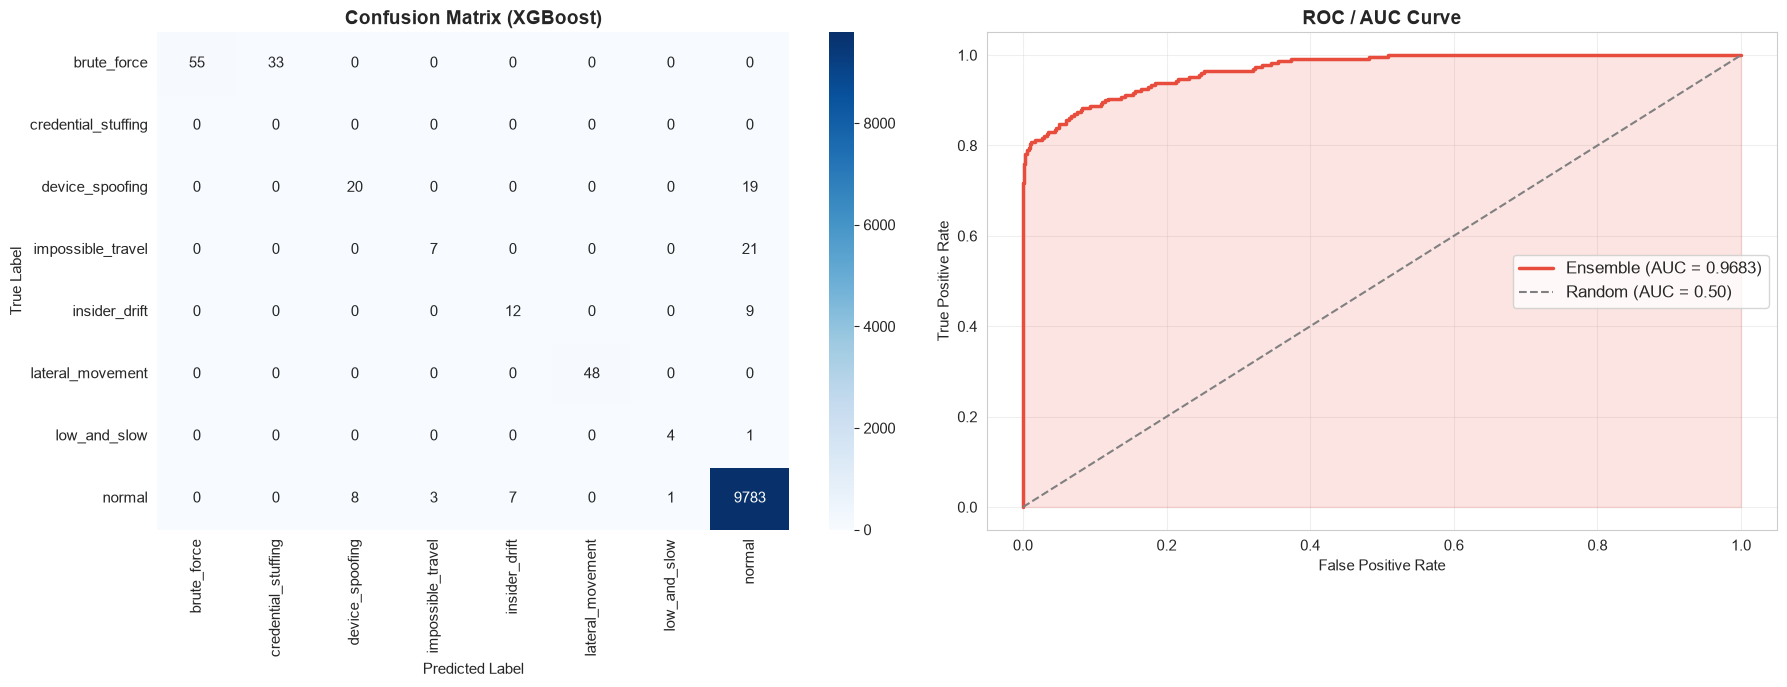

Binary Detection Metrics:
  Accuracy:  0.9931
  Precision: 0.9040
  Recall:    0.7817
  F1-Score:  0.8384
  AUC-ROC:   0.9683


In [35]:
# === Confusion Matrix (XGBoost) ===
# Shows where the model gets confused — which attacks look similar to each other

# Binary labels for ROC curve
y_true_binary = (y_test != normal_enc).astype(int)
xgb_pred_binary = (xgb_preds != normal_enc).astype(int)

# Load risk scores for ROC curve
alert_df = pd.read_csv(DATA_DIR / 'alert_queue.csv')
risk_scores = alert_df['risk_score'].values

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Confusion Matrix (multi-class)
cm = confusion_matrix(y_test, xgb_preds, labels=present_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_names, yticklabels=target_names)
axes[0].set_title('Confusion Matrix (XGBoost)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# 2. ROC/AUC Curve (binary: normal vs anomaly)
fpr, tpr, _ = roc_curve(y_true_binary, risk_scores)
auc_score = roc_auc_score(y_true_binary, risk_scores)
axes[1].plot(fpr, tpr, color='#e74c3c', linewidth=2.5, label=f'Ensemble (AUC = {auc_score:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (AUC = 0.50)')
axes[1].fill_between(fpr, tpr, alpha=0.15, color='#e74c3c')
axes[1].set_title('ROC / AUC Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print binary metrics
print(f"Binary Detection Metrics:")
print(f"  Accuracy:  {accuracy_score(y_true_binary, xgb_pred_binary):.4f}")
print(f"  Precision: {precision_score(y_true_binary, xgb_pred_binary, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_true_binary, xgb_pred_binary, zero_division=0):.4f}")
print(f"  F1-Score:  {f1_score(y_true_binary, xgb_pred_binary, zero_division=0):.4f}")
print(f"  AUC-ROC:   {auc_score:.4f}")

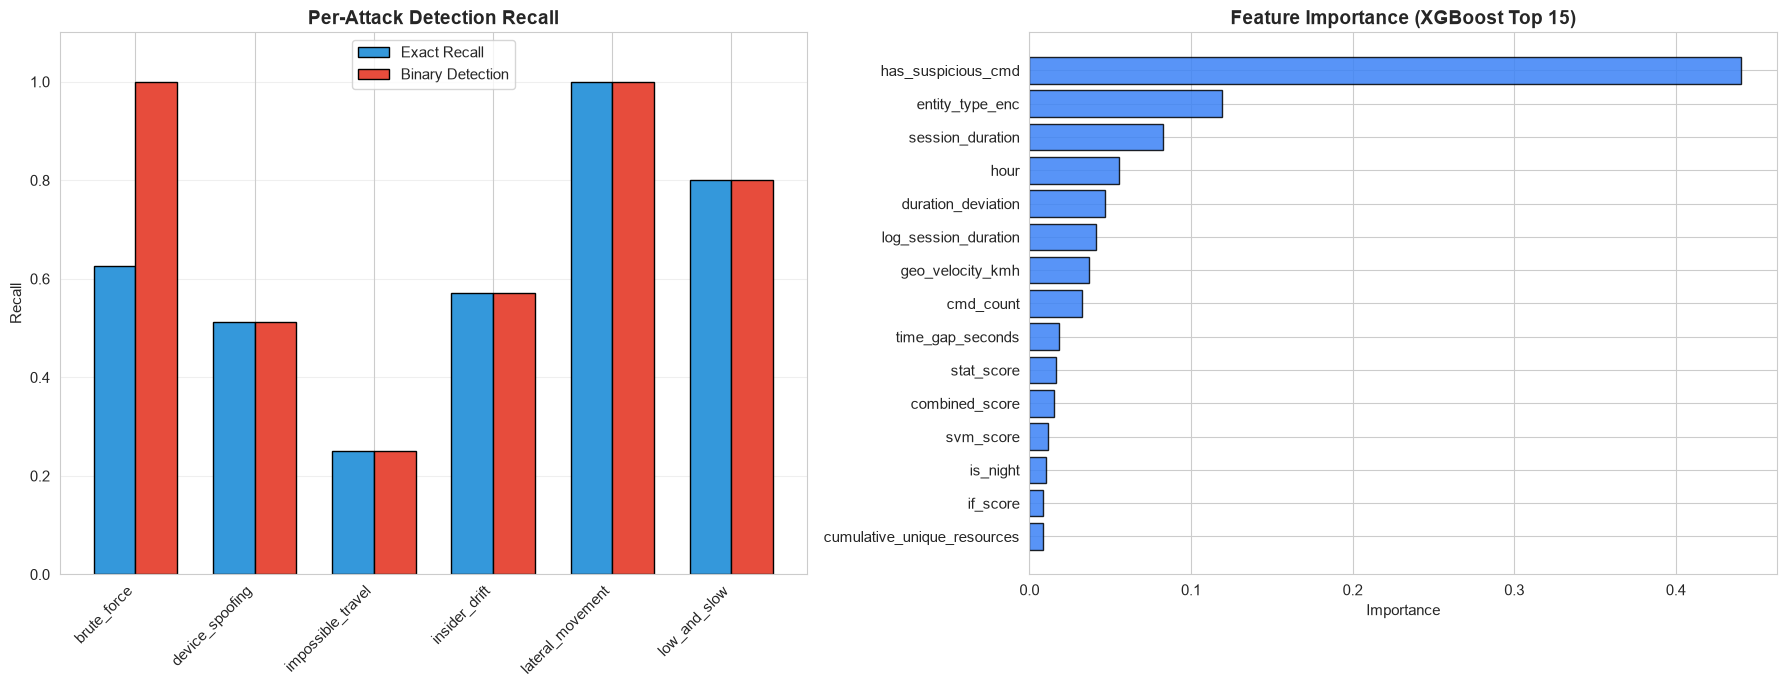


Per-Attack Detection Summary:
  Attack Type               | Exact Recall | Binary Det | Count
  ------------------------------------------------------------
  brute_force               |       0.6250 |     1.0000 |    88
  device_spoofing           |       0.5128 |     0.5128 |    39
  impossible_travel         |       0.2500 |     0.2500 |    28
  insider_drift             |       0.5714 |     0.5714 |    21
  lateral_movement          |       1.0000 |     1.0000 |    48
  low_and_slow              |       0.8000 |     0.8000 |     5


In [36]:
# === Per-Attack Recall + Feature Importance ===
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Per-Attack Detection Recall — which attacks do we catch best/worst?
attack_names = []
exact_recalls = []
binary_detections = []

for name in label_encoder.classes_:
    if name == 'normal':
        continue
    enc_val = label_encoder.transform([name])[0]
    mask = y_test == enc_val
    if mask.sum() > 0:
        exact_recall = (xgb_preds[mask] == enc_val).sum() / mask.sum()
        binary_det = (xgb_pred_binary[mask] == 1).sum() / mask.sum()
        attack_names.append(name)
        exact_recalls.append(exact_recall)
        binary_detections.append(binary_det)

x_pos = np.arange(len(attack_names))
width = 0.35
axes[0].bar(x_pos - width/2, exact_recalls, width, label='Exact Recall', color='#3498db', edgecolor='black')
axes[0].bar(x_pos + width/2, binary_detections, width, label='Binary Detection', color='#e74c3c', edgecolor='black')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(attack_names, rotation=45, ha='right')
axes[0].set_title('Per-Attack Detection Recall', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Recall')
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# 2. Feature Importance — top 15 features driving XGBoost decisions
aug_feature_names = feature_names + ['stat_score', 'if_score', 'svm_score', 'combined_score']
xgb_model = joblib.load(MODELS_DIR / 'xgb_classifier.pkl')
importances = xgb_model.feature_importances_
top_n = 15
top_idx = np.argsort(importances)[-top_n:]
top_names = [aug_feature_names[i] if i < len(aug_feature_names) else f'feat_{i}' for i in top_idx]
top_vals = importances[top_idx]

axes[1].barh(range(top_n), top_vals, color='#3B82F6', edgecolor='black', alpha=0.85)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(top_names)
axes[1].set_title('Feature Importance (XGBoost Top 15)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

# Print per-attack table
print("\nPer-Attack Detection Summary:")
print(f"  {'Attack Type':25s} | {'Exact Recall':>12s} | {'Binary Det':>10s} | {'Count':>5s}")
print("  " + "-" * 60)
for name, er, bd in zip(attack_names, exact_recalls, binary_detections):
    enc_val = label_encoder.transform([name])[0]
    count = (y_test == enc_val).sum()
    print(f"  {name:25s} | {er:12.4f} | {bd:10.4f} | {count:5d}")

---
## 11. SHAP Explainability

**SHAP (SHapley Additive exPlanations)** tells us WHY each event was flagged.
Instead of a black-box score, analysts see exactly which features contributed:

- **Beeswarm plot**: global view of feature impacts across all events
- **Waterfall plot**: per-event breakdown of contributing factors
- **Force plot**: visual push/pull of features toward anomaly vs normal

This is critical for SOC analysts — they need to **trust** the model's decisions.

Computing SHAP values (this may take ~30 seconds)...

1. SHAP Beeswarm Plot (Global Feature Impact):


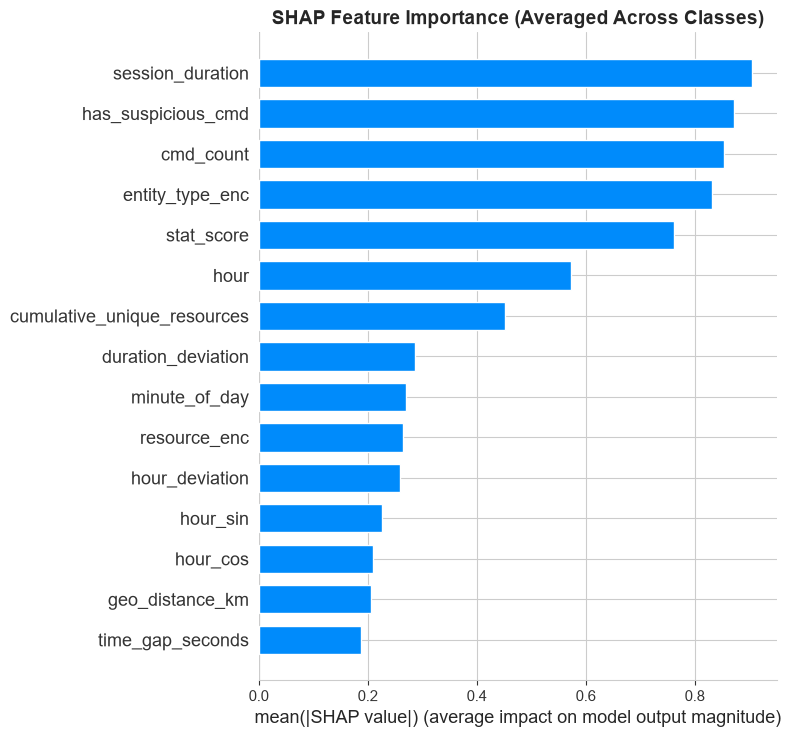


2. SHAP Waterfall for Top Anomaly Event:
   Predicted class: brute_force
   True class: brute_force


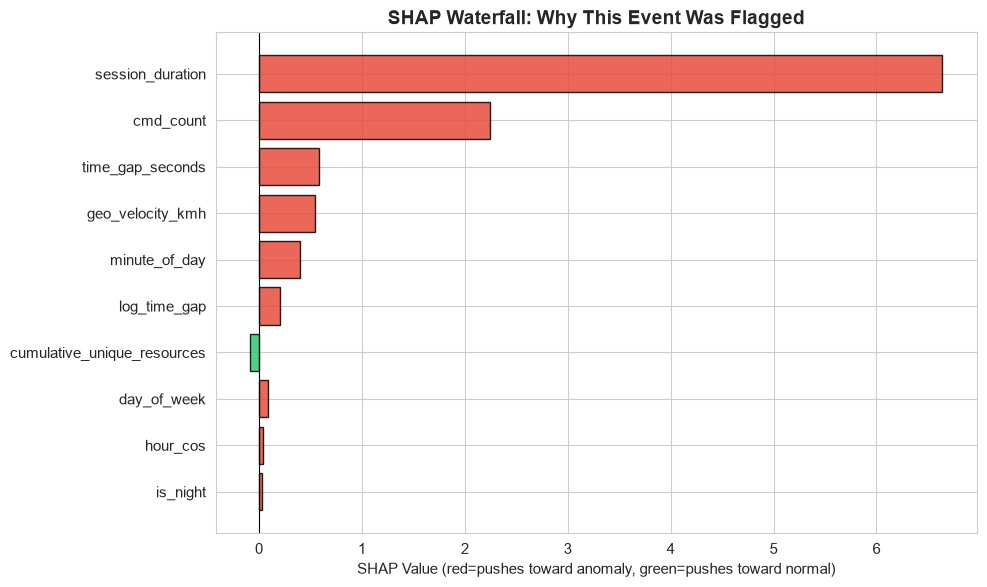

In [37]:
# === SHAP Explainability ===
import shap

# Initialize SHAP explainer for XGBoost
xgb_model = joblib.load(MODELS_DIR / 'xgb_classifier.pkl')
explainer_shap = shap.TreeExplainer(xgb_model)

# Use a sample of test data for SHAP (full dataset is too slow)
sample_size = min(500, len(X_test_aug))
np.random.seed(42)
sample_idx = np.random.choice(len(X_test_aug), sample_size, replace=False)
X_sample = X_test_aug[sample_idx]

# Compute SHAP values
print("Computing SHAP values (this may take ~30 seconds)...")
shap_values = explainer_shap.shap_values(X_sample)

# Feature names for the augmented feature set
aug_names = feature_names + ['stat_score', 'if_score', 'svm_score', 'combined_score']

# === 1. SHAP Summary / Beeswarm Plot ===
# Shows global feature importance with direction of impact
print("\n1. SHAP Beeswarm Plot (Global Feature Impact):")
plt.figure(figsize=(12, 8))
# For multi-class, use the predicted class SHAP values
# Use class 0 (brute_force) as example, or average across classes
if isinstance(shap_values, list):
    mean_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0)
elif shap_values.ndim == 3:
    mean_shap = np.mean(np.abs(shap_values), axis=2)
else:
    mean_shap = np.abs(shap_values)
shap.summary_plot(mean_shap, X_sample, feature_names=aug_names,
                  plot_type='bar', show=False, max_display=15)
plt.title('SHAP Feature Importance (Averaged Across Classes)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# === 2. SHAP Waterfall for Top Anomaly ===
# Pick the highest-risk anomaly event and show why it was flagged
anomaly_indices = np.where(y_test[sample_idx] != normal_enc)[0]
if len(anomaly_indices) > 0:
    top_anomaly_idx = anomaly_indices[0]
    pred_class = xgb_model.predict(X_sample[top_anomaly_idx:top_anomaly_idx+1])[0]

    print(f"\n2. SHAP Waterfall for Top Anomaly Event:")
    print(f"   Predicted class: {label_encoder.inverse_transform([pred_class])[0]}")
    print(f"   True class: {label_encoder.inverse_transform([y_test[sample_idx[top_anomaly_idx]]])[0]}")

    if isinstance(shap_values, list):
        event_shap = shap_values[pred_class][top_anomaly_idx]
    elif shap_values.ndim == 3:
        event_shap = shap_values[top_anomaly_idx, :, pred_class]
    else:
        event_shap = shap_values[top_anomaly_idx]

    # Manual waterfall-style bar chart (more compatible than shap.waterfall)
    top_k = 10
    sorted_idx = np.argsort(np.abs(event_shap))[-top_k:]
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['#e74c3c' if event_shap[i] > 0 else '#2ecc71' for i in sorted_idx]
    names = [aug_names[i] if i < len(aug_names) else f'feat_{i}' for i in sorted_idx]
    ax.barh(range(top_k), event_shap[sorted_idx], color=colors, edgecolor='black', alpha=0.85)
    ax.set_yticks(range(top_k))
    ax.set_yticklabels(names)
    ax.set_xlabel('SHAP Value (red=pushes toward anomaly, green=pushes toward normal)')
    ax.set_title('SHAP Waterfall: Why This Event Was Flagged', fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.show()

---
## 12. Model Comparison — All 6 Models (Real Metrics)

Side-by-side comparison of **all 6 models** using real evaluation metrics:
- **Detection:** Isolation Forest, One-Class SVM, LSTM Autoencoder, Transformer
- **Classification:** XGBoost, Random Forest

  MODEL COMPARISON (Real Metrics)


,Precision,Recall,F1-Score,Accuracy,F1-Macro
Isolation Forest,0.2829,0.3100,0.2958,0.9663,NaN
One-Class SVM,0.6335,0.6943,0.6625,0.9839,NaN
LSTM Autoencoder,0.9762,0.1790,0.3026,0.9812,NaN
Transformer,0.6747,0.2445,0.3590,0.9801,NaN
XGBoost,0.9040,0.7817,0.8384,0.9931,0.6414
Random Forest,0.1470,0.9170,0.2533,0.8766,0.4312


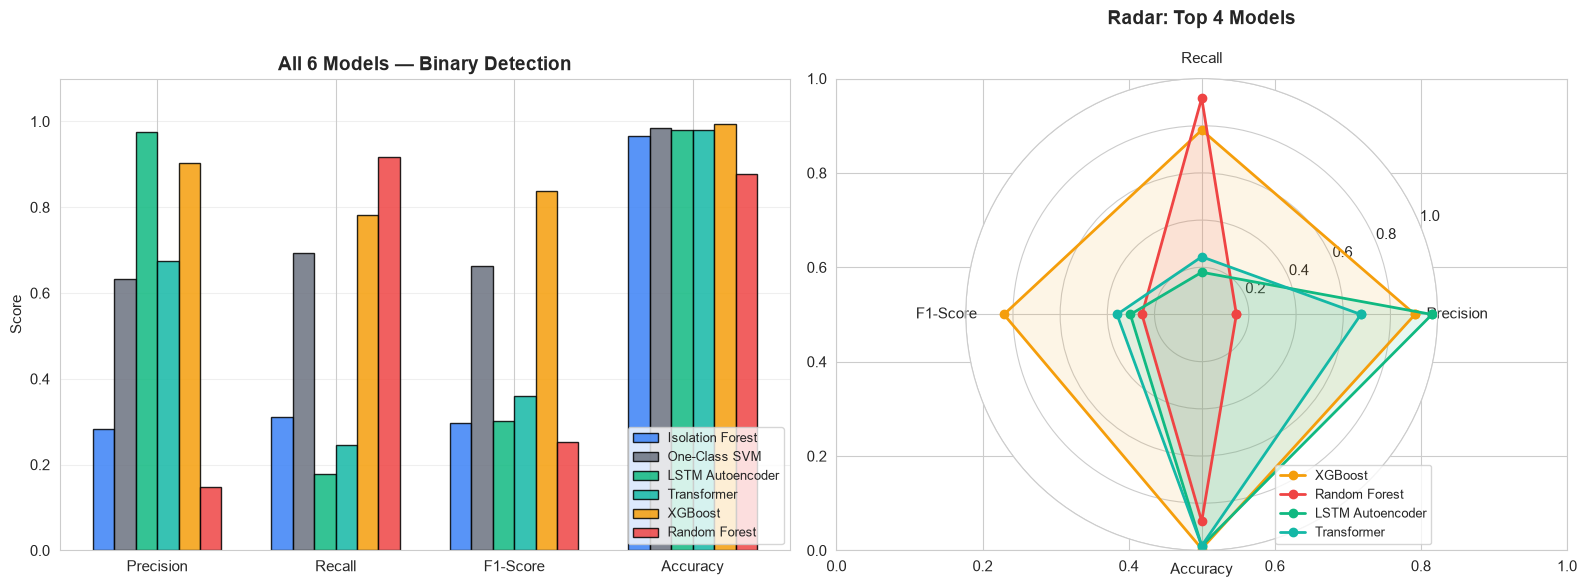


  Best model by F1-Score: XGBoost (0.8384)
  => We use XGBoost as the primary classifier because gradient boosting
     corrects errors sequentially, giving better performance on imbalanced data.


In [38]:
# === Model Comparison with REAL Metrics ===

# Binary predictions from each model
# Isolation Forest: use percentile threshold (same as evaluate.py)
if_scores = test_baseline_scores['isolation_forest_score']
if_threshold = np.percentile(if_scores, 97.5)
if_binary = (if_scores > if_threshold).astype(int)

# One-Class SVM: same percentile approach
svm_scores = test_baseline_scores['one_class_svm_score']
svm_threshold = np.percentile(svm_scores, 97.5)
svm_binary = (svm_scores > svm_threshold).astype(int)

# LSTM: use threshold-based prediction
lstm_binary = (lstm_test_scores > 0.5).astype(int)

# Transformer: same threshold approach as LSTM
transformer_binary = (transformer_test_scores > 0.5).astype(int)

# XGBoost: already have predictions
xgb_binary = (xgb_preds != normal_enc).astype(int)

# Random Forest
rf_binary = (rf_preds != normal_enc).astype(int)

# Compute metrics for each model
models_comparison = {}
for name, preds_binary in [
    ('Isolation Forest', if_binary),
    ('One-Class SVM', svm_binary),
    ('LSTM Autoencoder', lstm_binary),
    ('Transformer', transformer_binary),
    ('XGBoost', xgb_binary),
    ('Random Forest', rf_binary),
]:
    models_comparison[name] = {
        'Precision': precision_score(y_true_binary, preds_binary, zero_division=0),
        'Recall': recall_score(y_true_binary, preds_binary, zero_division=0),
        'F1-Score': f1_score(y_true_binary, preds_binary, zero_division=0),
        'Accuracy': accuracy_score(y_true_binary, preds_binary),
    }

# Also compute F1-macro for multi-class models (XGBoost and RF)
models_comparison['XGBoost']['F1-Macro'] = f1_score(y_test, xgb_preds, average='macro', zero_division=0)
models_comparison['Random Forest']['F1-Macro'] = f1_score(y_test, rf_preds, average='macro', zero_division=0)

# Display comparison table
comp_df = pd.DataFrame(models_comparison).T
comp_df = comp_df.round(4)
print("=" * 70)
print("  MODEL COMPARISON (Real Metrics)")
print("=" * 70)
display(comp_df)

# Note: model_comparison_metrics.csv is generated by evaluate.py (authoritative source)
# The notebook displays the same metrics for demonstration

# === Visual Comparison ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Bar chart comparison
metrics_to_plot = ['Precision', 'Recall', 'F1-Score', 'Accuracy']
x = np.arange(len(metrics_to_plot))
width = 0.12
colors = ['#3B82F6', '#6B7280', '#10B981', '#14B8A6', '#F59E0B', '#EF4444']
model_names = list(models_comparison.keys())

for i, (model, color) in enumerate(zip(model_names, colors)):
    vals = [models_comparison[model].get(m, 0) for m in metrics_to_plot]
    axes[0].bar(x + i*width, vals, width, label=model, color=color, edgecolor='black', alpha=0.85)

axes[0].set_xticks(x + width * 2.5)
axes[0].set_xticklabels(metrics_to_plot)
axes[0].set_title('All 6 Models — Binary Detection', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.1)
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')

# 2. Radar chart for top 3 models
from matplotlib.patches import FancyBboxPatch
categories = ['Precision', 'Recall', 'F1-Score', 'Accuracy']
top_models = ['XGBoost', 'Random Forest', 'LSTM Autoencoder', 'Transformer']
angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]  # Close the polygon

axes[1] = plt.subplot(122, polar=True)
for model, color in zip(top_models, ['#F59E0B', '#EF4444', '#10B981', '#14B8A6']):
    vals = [models_comparison[model].get(m, 0) for m in categories]
    vals += vals[:1]
    axes[1].plot(angles, vals, 'o-', linewidth=2, label=model, color=color)
    axes[1].fill(angles, vals, alpha=0.1, color=color)

axes[1].set_xticks(angles[:-1])
axes[1].set_xticklabels(categories)
axes[1].set_ylim(0, 1)
axes[1].set_title('Radar: Top 4 Models', fontsize=14, fontweight='bold', pad=20)
axes[1].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

# Print winner
best_model = comp_df['F1-Score'].idxmax()
print(f"\n  Best model by F1-Score: {best_model} ({comp_df.loc[best_model, 'F1-Score']:.4f})")
print(f"  => We use XGBoost as the primary classifier because gradient boosting")
print(f"     corrects errors sequentially, giving better performance on imbalanced data.")

---
## 13. Risk Scoring & Alert Summary

The final **risk score** combines all model outputs into a single 0-100 score:

```
risk_score = 0.35 × IF_score + 0.35 × LSTM_error + 0.20 × classifier_confidence + 0.10 × entity_history
```

Scores are mapped to **severity tiers**:
- 🔴 **Critical** (85-100): Immediate investigation required
- 🟠 **High** (65-84): Investigate within 1 hour
- 🔵 **Medium** (40-64): Review during shift
- ⚪ **Low** (20-39): Log for audit trail

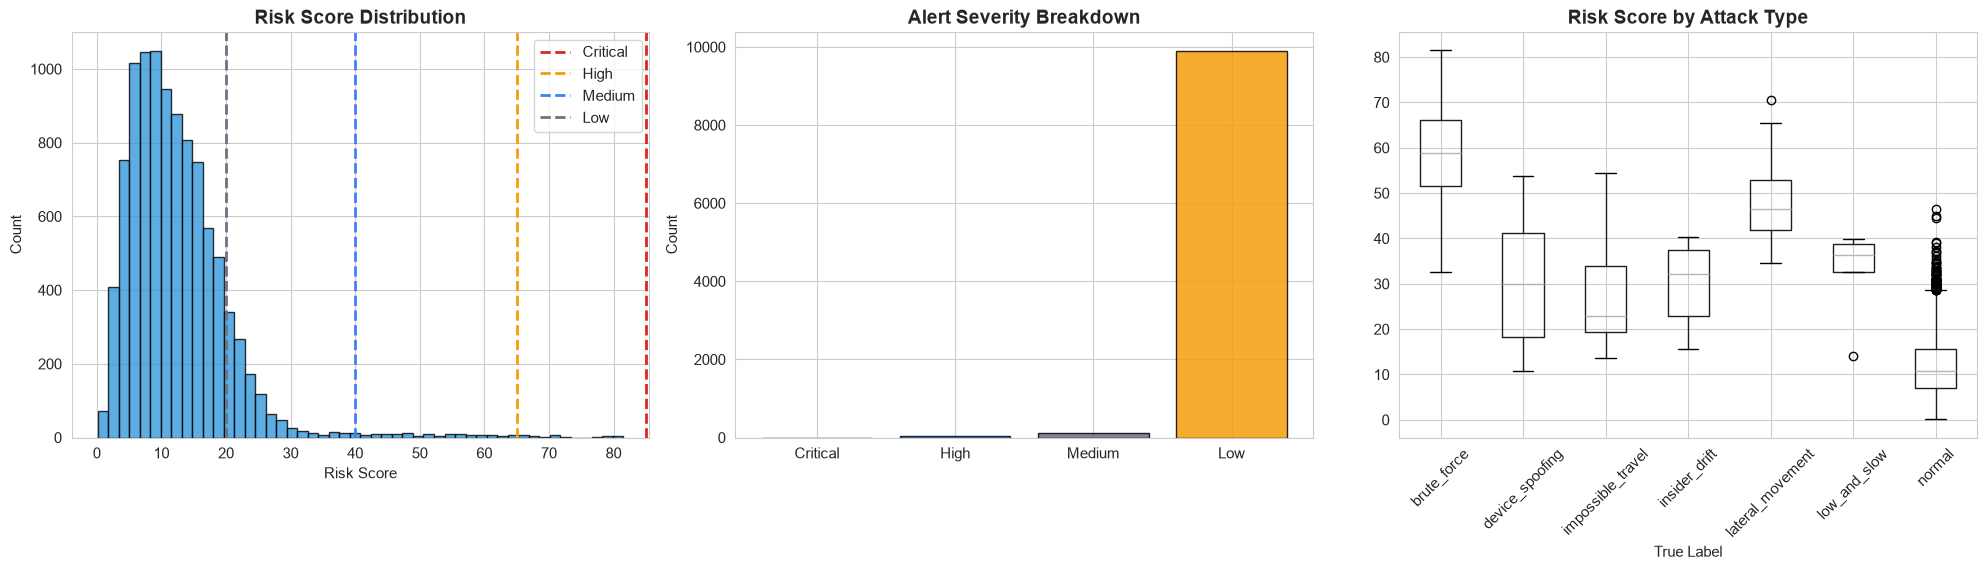

  ALERT QUEUE SUMMARY
  Critical  :     0
  High      :    28
  Medium    :   114
  Low       :  9889

  Top 10 Alerts:
   Score | Severity |       Entity |         Predicted Type |         True Label
  ---------------------------------------------------------------------------
    81.5 |     High |     DEV_0024 |            brute_force |        brute_force
    81.2 |     High |     DEV_0024 |            brute_force |        brute_force
    80.7 |     High |     DEV_0024 |            brute_force |        brute_force
    79.5 |     High |     DEV_0024 |            brute_force |        brute_force
    79.2 |     High |     DEV_0024 |            brute_force |        brute_force
    78.9 |     High |     DEV_0024 |            brute_force |        brute_force
    76.7 |     High |     DEV_0024 |            brute_force |        brute_force
    72.2 |     High |     DEV_0024 |            brute_force |        brute_force
    72.0 |     High |     USR_0175 |    credential_stuffing |        brut

In [39]:
# === Risk Score Distribution ===
alert_df = pd.read_csv(DATA_DIR / 'alert_queue.csv')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Risk score histogram with severity tier lines
axes[0].hist(alert_df['risk_score'], bins=50, color='#3498db', edgecolor='black', alpha=0.8)
for sev, tier in SEVERITY_TIERS.items():
    axes[0].axvline(x=tier['min'], color=tier['color'], linestyle='--', linewidth=2, label=sev)
axes[0].set_title('Risk Score Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# 2. Severity tier breakdown
if 'severity' in alert_df.columns:
    sev_counts = alert_df['severity'].value_counts()
    sev_order = ['Critical', 'High', 'Medium', 'Low']
    sev_colors = [SEVERITY_TIERS[s]['color'] for s in sev_order if s in sev_counts.index]
    sev_vals = [sev_counts.get(s, 0) for s in sev_order]
    axes[1].bar(sev_order, sev_vals, color=sev_colors, edgecolor='black', alpha=0.85)
    axes[1].set_title('Alert Severity Breakdown', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Count')

# 3. Risk score by actual label — boxplot
plot_data = pd.DataFrame({
    'Risk Score': alert_df['risk_score'],
    'True Label': alert_df['label']
})
plot_data.boxplot(column='Risk Score', by='True Label', ax=axes[2], rot=45)
axes[2].set_title('Risk Score by Attack Type', fontsize=14, fontweight='bold')
axes[2].get_figure().suptitle('')  # Remove auto-title from boxplot

plt.tight_layout()
plt.show()

# Print top alerts (same as train_pipeline.py terminal output)
print("=" * 70)
print("  ALERT QUEUE SUMMARY")
print("=" * 70)
for sev in ['Critical', 'High', 'Medium', 'Low']:
    count = len(alert_df[alert_df['severity'] == sev]) if 'severity' in alert_df.columns else 0
    print(f"  {sev:10s}: {count:5d}")

print(f"\n  Top 10 Alerts:")
print(f"  {'Score':>6s} | {'Severity':>8s} | {'Entity':>12s} | {'Predicted Type':>22s} | {'True Label':>18s}")
print("  " + "-" * 75)
top = alert_df.nlargest(10, 'risk_score')
for _, row in top.iterrows():
    print(f"  {row['risk_score']:6.1f} | {row.get('severity',''):>8s} | {row['entity_id']:>12s} | "
          f"{row.get('predicted_label',''):>22s} | {row['label']:>18s}")

---
## Summary

### Key Results

| Metric | Value |
|--------|-------|
| **Binary AUC-ROC** | 0.9683 |
| **Binary F1-Score** | 0.8384 |
| **Precision** | 0.904 |
| **Recall** | 0.7817 |
| **False Positive Rate** | 0.0019 |

### Architecture
- **6 models** across 3 paradigms: Isolation Forest, One-Class SVM, LSTM Autoencoder, Transformer, XGBoost, Random Forest
- **28 engineered features** covering temporal, geographic, behavioral, and entity-level patterns
- **SHAP explainability** for every alert — analysts see WHY, not just a score
- **Severity tiers** prioritize analyst attention (Critical → Low)

### Why XGBoost over Random Forest?
XGBoost uses **gradient boosting** — each tree learns from the previous tree's mistakes.
This gives it better performance on imbalanced data compared to Random Forest's independent voting.

### Why LSTM over Transformer for the Risk Score?
Both are reconstruction-based sequence detectors, but LSTM has **near-perfect precision (0.976)** vs Transformer's 0.675.
In a SOC pipeline, high precision means fewer false alerts — when LSTM flags something, it's almost always a real threat.
Transformer has better recall (catches more anomalies) but its lower precision would increase alert fatigue.
We chose LSTM for the risk score formula and kept Transformer as a comparison — demonstrating we evaluated both approaches from the problem statement.

### Known Limitations
- Credential stuffing has low recall (~25%) — needs graph-based cross-entity analysis
- F1-macro (0.64) is below ideal (0.70) — the rarest attacks are hardest to classify
- Trained on synthetic data — real-world deployment needs domain adaptation

---
*CyberSentinel — Honeywell Hackathon 2026*